# Main Pipeline Scan Planning

This notebook documents how individual observing sessions of the Lab 4 galactic-plane HI survey are *formed*: from the abstract sampling grid down to the ordered list of cells the Leuschner dish actually visits during a single window of operating hours. The driver script `scripts/main/main` is config-only and delegates all planning to `scripts/main/_survey.py`. The exposition here mirrors that logic, makes the theoretical assumptions explicit, and renders representative coverage from real archived sessions in both galactic ($\ell, b$) and topocentric (alt, az) coordinates.

## 1. Motivation

The science targets in `lab_dish/HI1.tex` (galactic-plane rotation curve, plane warp, North Polar Spur, NCP supershell, etc.) all require *maps*: dense sampling of the 21 cm line over hundreds of square degrees in galactic coordinates. The smallest such project lists $\sim 400$ pointings; the largest, $\sim 10\,000$ pointings. At our Leuschner integration time of $\sim 60$ s on-source per cell (set by SNR requirements at the dish's nominal $T_{\rm sys} \sim 200$ K and the bandwidth-shifted frequency-switching scheme), a full survey requires tens of hours of dish time spread over multiple nights.

Two facts constrain how that time is spent.

1. **Cells are only accessible for part of each sidereal day.** A given $(\ell, b)$ traces an alt/az curve set by Leuschner's latitude ($+37.92^\circ$). Cells north of the celestial equator dip behind the dish's lower altitude limit ($17^\circ$); cells very near the celestial pole bump against the upper limit ($83^\circ$); the azimuth cable wrap forbids a wedge near az$=0/360^\circ$. Cells that are visible *now* will not be visible *in three hours*, and vice versa.

2. **The dish is slow.** A typical inter-cell slew + per-cell schedule (ABBA frequency switch, four cal dumps plus eight obs dumps) totals $\approx 95$ s. A drift-monitoring excursion to a near-circumpolar recal field (presently a single pointing at $(\mathrm{RA},\,\mathrm{Dec}) = (90^\circ, +72^\circ)$, which transits between alt $\approx 20^\circ$ and $56^\circ$ at our latitude and so is comfortably inside the dish's $[17^\circ, 83^\circ]$ altitude band at every sidereal time) runs every ten cells and burns $\approx 305$ s. Once a cell is committed to the queue, several minutes elapse before the dish reaches it; alt/az drifts $\sim 1^\circ$ in that window.

Together these mean we cannot statically partition the survey into sessions. Each session must be planned *forward* from the moment the script starts: pick the cells the dish will still be able to reach when the scan order brings the executor to them, and skip the ones the sky will have rotated out of by then. The rest of this notebook walks through that planning, then visualises what comprehensive sessions look like on the ground.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ugradiolab.plotting as plotting

from plotters import plot_session_coverage
from utils.io import rank_sessions_by_contiguity
from utils.mapping import build_galplane_grid

%matplotlib inline

# Survey grid parameters (mirror scripts/main/main : SurveyConfig).
L_CENTER = 120.0
L_MIN, L_MAX = -60.0, 300.0
B_MIN, B_MAX = -20, 20
B_STEP = 2
PHYSICAL_SPACING_DEG = 2.0

# Beam (HPBW ~ 3.4 deg at 1.4 GHz on the 4.5 m dish).
HPBW_DEG = 3.4

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. The galactic-coordinate sampling grid

The HI1 instructions (\S 8 in the LaTeX source) prescribe Nyquist sampling at *two samples per FWHM* in great-circle distance. With our $4.5$ m dish's HPBW of $\approx 3.4^\circ$ at $1.42$ GHz, that yields a $2^\circ$ angular spacing.

A naive $(\Delta \ell, \Delta b) = (2^\circ, 2^\circ)$ grid oversamples in $\ell$ at high $|b|$: the great-circle distance between two cells at fixed $\ell$-step is $\Delta \ell \cdot \cos(b)$, so near the poles a $2^\circ$ step is much smaller than the beam. We correct this with $\Delta \ell = 2^\circ / \cos(b)$ at each $b$ row, which preserves uniform great-circle sampling and reduces total cell count substantially toward higher $|b|$.

A second refinement is the **brick-interleave**: two phases of the grid, even ($b \in \{-20, -18, \ldots, 20\}$ at $\ell$ centered on $\ell_0 = 120^\circ$) and odd ($b \in \{-19, -17, \ldots, 19\}$ with $\ell$ offset by half a step). Stacked, the two phases approximate a hexagonal sampling pattern: each cell's six nearest neighbours -- two same-row at $\Delta \ell = 2^\circ / \cos b$, four diagonal at $(\Delta \ell, \Delta b) = (1^\circ / \cos b,\, 1^\circ)$ -- sit on a great-circle distance of $\approx \sqrt{2}^\circ \approx 1.41^\circ$, which is below the formal Nyquist spacing of $\mathrm{HPBW}/2 = 1.7^\circ$ for a $3.4^\circ$ beam.

Why aim for Nyquist? The dish is a low-pass filter on the sky: the response to a point source is the beam pattern $B(\theta)$, whose Fourier transform $\tilde B(u)$ falls off above a half-power spatial frequency $u_{1/2} \approx 1/\mathrm{HPBW} \approx 0.29\ \mathrm{cyc/deg}$ and is effectively zero beyond a few times that. By the sampling theorem, an angular sampling pitch $\Delta \theta \le 1/(2 u_{1/2}) = \mathrm{HPBW}/2 = 1.7^\circ$ is sufficient to reconstruct the beam-smoothed sky exactly (in the limit of perfect SNR). A single-phase $2^\circ / \cos b$ grid by itself gives nearest-neighbour spacing $2^\circ$ -- a factor $\sim 1.18$ short of Nyquist -- so structures with angular wavelength between $2 \times 1.7^\circ = 3.4^\circ$ and $2 \times 2^\circ = 4^\circ$ alias into the reconstructed map as low-frequency ripple at the few-percent-of-peak level. Brick-interleaving brings the nearest-neighbour distance to $\sqrt 2^\circ \approx 1.41^\circ$ and pushes that aliasing band off the sky entirely, at the cost of doubling the number of pointings. We currently run only the even phase (`phases=('even',)` in the driver) to complete baseline coverage first; the odd-phase entrypoint is preserved for a second pass that will close the loop to full Nyquist sampling.

Cells are stored in *column-major* order: contiguous runs at fixed $\ell$ swept through $b$, zig-zagged so successive cells share an azimuth. This minimises slew time relative to a row-major sweep that would otherwise jump across the full $\ell$ range on every row break.

In [2]:
even_grid = build_galplane_grid(
    b_min=B_MIN, b_max=B_MAX, b_step=B_STEP,
    l_min=L_MIN, l_max=L_MAX, l_center=L_CENTER,
    physical_spacing_deg=PHYSICAL_SPACING_DEG,
    phase='even',
)


## 3. Telescope-induced sky accessibility

Before forward-simulating any particular session, it helps to look at which cells are *ever* reachable at all. The static never-observable mask sweeps hour-angle through a full sidereal day and asks: does there exist any HA at which this $(\ell, b)$ satisfies

$$17^\circ \le \mathrm{alt} \le 83^\circ \quad \text{and} \quad 7^\circ \le \mathrm{az} \le 348^\circ ?$$

Cells that fail at every HA are *permanently* invisible from Leuschner. These are the deep southern declinations (cells whose maximum altitude is below $17^\circ$, i.e.\ $\delta \lesssim -35^\circ$) and a circumpolar cap near the NCP, which is excluded by both the upper altitude limit ($\delta \gtrsim 90^\circ - (90^\circ - 37.92^\circ) - 83^\circ = +30.9^\circ$ transits above $83^\circ$, though only a small dec range stays there long) and -- more importantly -- the cable-wrap wedge near az$=0/360^\circ$: as $\delta \to 90^\circ$ the source sits essentially due north for the entire diurnal track and never leaves the dead wedge. The remaining cells are visible for at least one window per sidereal day, but the windows are not synchronous with each other.

## 4. Forming a session by forward simulation

A session is the cell list produced by *one* invocation of `plan_phase` in `_survey.py`. The driver loops `plan_phase` $\to$ execute forever; each top-of-loop call rebuilds the plan against the current wallclock, so cells naturally roll in as they rise and out as they set.

Within one call the planning logic is:

1. **Build** the full grid for the active phase.
2. **Filter by az side.** Each cell's instantaneous az at $t=t_0$ classifies it as *rising* (az $\in [7^\circ, 180^\circ]$) or *setting* (az $\in (180^\circ, 348^\circ]$). Side selection picks whichever side has more *currently accessible* cells. This avoids the cable-wrap penalty in `Beware Operating near Azimuth 0/360` (HI1.tex \S 7.2): the dish never crosses the $0/360$ seam within a session.
3. **Drop already-complete cells** via the completeness index (a per-LO, per-kind dump counter built from the on-disk `data/main/session_*/<cell>/*.npz` filenames). Cells whose dump counts already meet the schedule's target are skipped; cells listed in `artifacts/main_reobserve.json` are forced in regardless.
4. **Forward-simulate.** Walk the surviving cells in column-major order. For each cell $i$ project its observation time as

$$t_i = t_0 + (i + 0.5) \, t_\text{cell} + n_\text{recal}(i) \, t_\text{recal},$$

where $t_\text{cell}$ is the empirically measured p50 per-cell duration (from `timing_stats`), $t_\text{recal} = 305$ s is the p90 of an end-to-end recal cycle, and $n_\text{recal}(i) = 1 + \lfloor i / 10 \rfloor$ accounts for the start-of-session warm-up plus injected drift checks every $10$ cells. Evaluate alt/az at $t_i$ via the cached ICRS $\to$ Leuschner closed-form transform (matches astropy to $< 1^\circ$ everywhere, much faster) and keep the cell only if it still passes the alt/az limits.
5. **Horizon cut.** Cells whose projected $t_i - t_0 > 4$ hours are dropped: anything that far out will be re-planned by the next top-of-loop iteration anyway, and committing to it would let runtime drift accumulate.
6. **Strategy selection.** Steps 4--5 are repeated for the four column-major sweep variants (l ascending/descending $\times$ b ascending/descending) on both az sides; the variant with the most survivors wins.

The output of `plan_phase` is the *cell list*: an ordered sequence of $(\ell, b)$ that the executor will visit, interleaved at runtime with recal cells from `RECAL_TARGETS` -- currently a single near-circumpolar pointing at $(\mathrm{RA},\,\mathrm{Dec}) = (90^\circ, +72^\circ)$. Two candidates were originally configured (the other at RA$=180^\circ$); restricting to one halves the time spent on drift-monitoring without compromising the diagnostic, since the chosen target is observable at every sidereal time.

In [3]:
sessions = rank_sessions_by_contiguity('data/main')

## 5. Per-session coverage in both coordinate systems

Side-by-side rendering of the longest contiguous archived session in `data/main`. Each on-disk session in `data/main/session_NNN/` is a directory of `obs_<l>_<b>/` and `cal_<l>_<b>/` subdirectories whose `.npz` filenames encode UTC dump timestamps; the scan order is reconstructed by sorting cells on their earliest dump time, and the observed alt/az is recomputed from the cell's $(\ell, b)$ at that time via the same closed-form ICRS$\to$Leuschner transform used by the executor's forward simulator. Recal-drift pointings (`obs_recal_drift[_bk]_<l>_<b>/`) are recovered alongside science cells; they appear as red crosses in both panels and the dashed track threads them in time order, so the off-grid drift-monitoring detours every ~10 cells are visible.

* **Left (topocentric Mollweide).** Red hatching marks the dish's inaccessible regions (alt cuts at $17^\circ$ and $83^\circ$ plus the cable-wrap wedge around az $= 0/360^\circ$); one small dot per science pointing, coloured by hours into the session; recal pointings are red crosses; a dashed great-circle track threads everything in observation order. The az-side selection is obvious: the science cells sit cleanly on one hemisphere and never cross the cable-wrap seam.

* **Right (galactic flat-sky).** The same cells in $(\ell, b)$. Each science beam is outlined faintly as an ellipse with semi-major $\mathrm{HPBW}/2$ in $b$ and $(\mathrm{HPBW}/2)/\cos(b)$ in $\ell$, so its on-sky footprint is a great-circle small circle of diameter $3.4^\circ$ regardless of latitude. A central dot marks each pointing; the recal pointing (off the survey grid, at $(\mathrm{RA},\,\mathrm{Dec}) = (90^\circ, +72^\circ)$, near-circumpolar at Leuschner so it can be observed at any sidereal time) are red crosses; the dashed track exposes the column-major zig-zag the planner emits plus the periodic excursions to the recal targets. The full survey grid is rendered faintly behind for context.

Both panels share the colour scale and the single colour bar below.

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


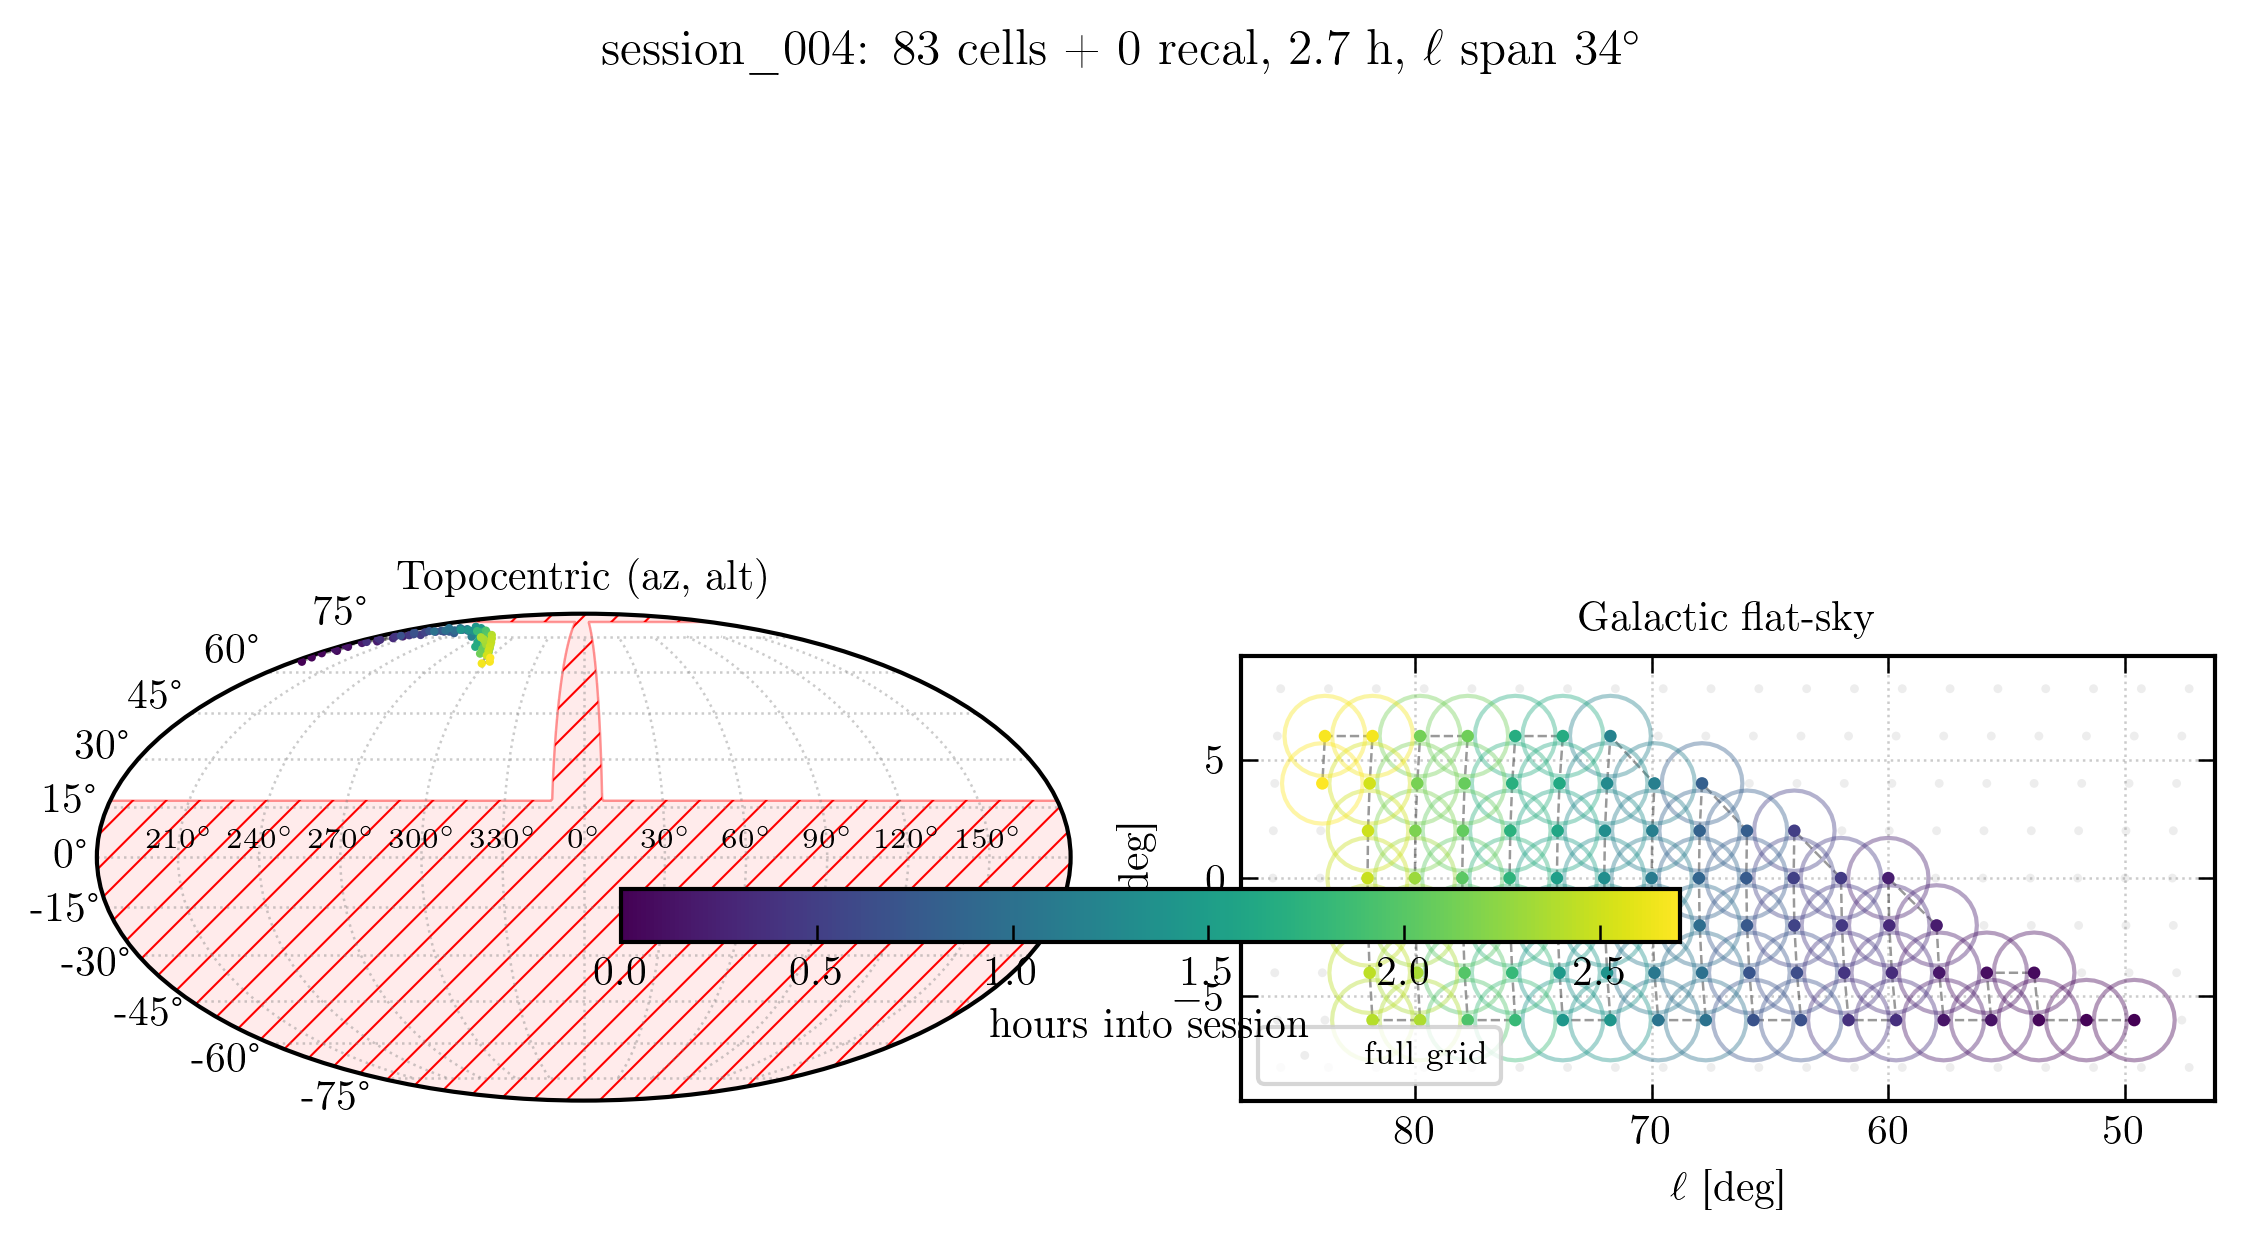

In [4]:
plot_session_coverage(sessions[0], even_grid, hpbw_deg=HPBW_DEG)
plt.show()